In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import scipy as scipy

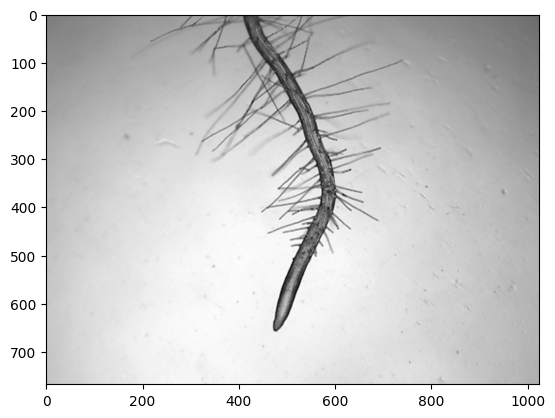

In [16]:
image_path = "/Users/antoantony/Root_Hair/9-30/KO/KO 10 um T0/KO 10 um_4.bmp"
image_path2 = '/Users/antoantony/Root_hair_test_stuff/root_hair_150/images/predict/134.bmp'
image_gray = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)

plt.imshow(image_gray, cmap='gray')
plt.show()

Binary inverse threshold

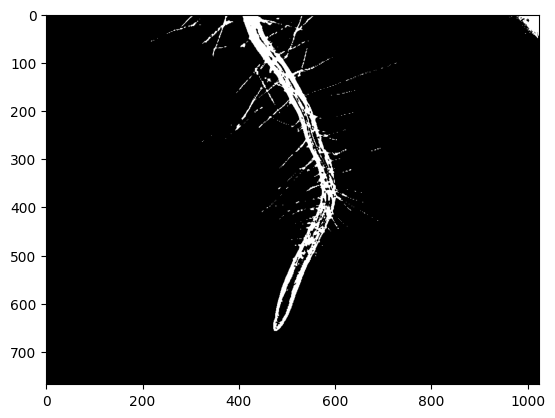

In [17]:
_, mask = cv2.threshold(image_gray, 110, 255, cv2.THRESH_BINARY_INV)

plt.imshow(mask, cmap='gray')
plt.show()

Kernel

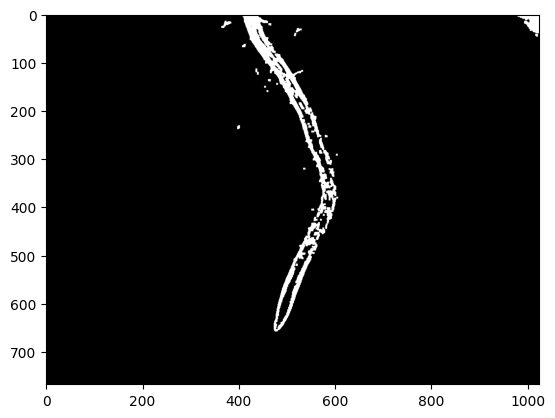

In [18]:
kernel = np.ones((4,4), np.uint8)
opened_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

plt.imshow(opened_mask, cmap='gray')
plt.show()

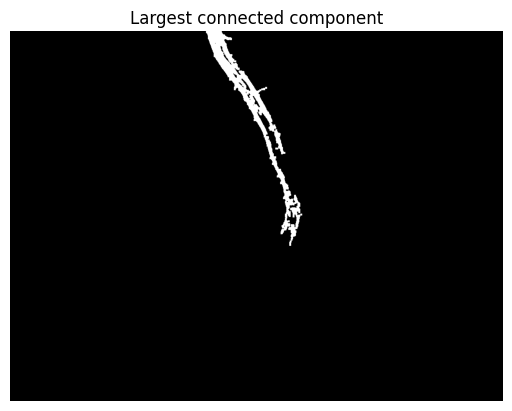

In [19]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opened_mask, connectivity=8)

# skip label 0 because that's background
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

main_root_mask = np.zeros_like(opened_mask)
main_root_mask[labels == largest_label] = 255

plt.imshow(main_root_mask, cmap='gray')
plt.title("Largest connected component")
plt.axis("off")
plt.show()

Adaptive threshold 

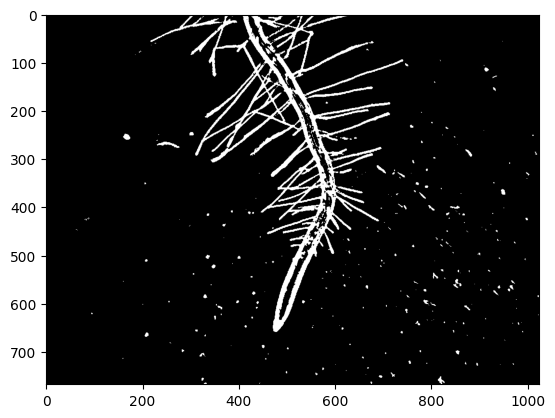

In [20]:
adapt = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    35,   # block size, must be odd
    8     # constant subtracted
)

plt.imshow(adapt, cmap='gray')
plt.show()



vertical kernel, adaptive threshold, then connected component

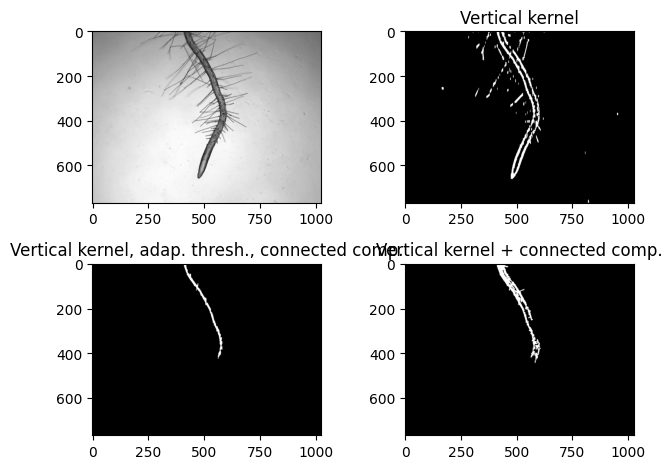

In [21]:
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,10))
vert_opened = cv2.morphologyEx(adapt, cv2.MORPH_OPEN, vertical_kernel)

num_labels2, labels2, stats2, centroids2 = cv2.connectedComponentsWithStats(vert_opened, connectivity=8)

# skip label 0 because that's background
largest_label2 = 1 + np.argmax(stats2[1:, cv2.CC_STAT_AREA])

main_root_mask2 = np.zeros_like(vert_opened)
main_root_mask2[labels2 == largest_label2] = 255

# plt.imshow(vert_opened, cmap='gray')
# plt.show()

# plt.imshow(main_root_mask2, cmap='gray')
# plt.title("Largest connected component")
# plt.axis("off")
# plt.show()

# plt.imshow(image_gray, cmap='gray')
# plt.show()

fig, ax = plt.subplots(2,2)
ax[0,0].imshow(image_gray, cmap='gray')
ax[0,1].imshow(vert_opened, cmap='gray')
ax[0,1].set_title("Vertical kernel")
ax[1,0].imshow(main_root_mask2, cmap='gray')
ax[1,0].set_title("Vertical kernel, adap. thresh., connected comp.")
ax[1,1].imshow(main_root_mask, cmap='gray')
ax[1,1].set_title("Vertical kernel + connected comp.")

plt.tight_layout()
plt.show()

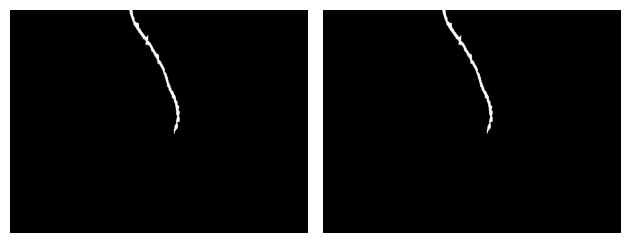

In [22]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed = cv2.morphologyEx(main_root_mask2, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours2, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
main_contour = max(contours, key=cv2.contourArea)
main_contour2 = max(contours2, key=cv2.contourArea)

mask_closed_contour = np.zeros_like(main_root_mask2)
mask_closed_contour2 = np.zeros_like(main_root_mask2)
cv2.drawContours(mask_closed_contour, [main_contour], -1, 255, -1 #or cv2.FILLED)
)
cv2.drawContours(mask_closed_contour2, [main_contour2], -1, 255, -1)

fig, ax = plt.subplots(1,2)
ax[0].imshow(mask_closed_contour, cmap='gray')
ax[0].axis("off")
ax[1].imshow(mask_closed_contour2, cmap='gray')
ax[1].axis("off")
plt.tight_layout()
plt.show()

In [23]:
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
# closed = cv2.morphologyEx(main_root_mask2, cv2.MORPH_CLOSE, kernel)

# contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# main_contour = max(contours, key=cv2.contourArea)

# mask_closed_contour = np.zeros_like(main_root_mask2)
# cv2.drawContours(mask_closed_contour, [main_contour], -1, 255, -1)

# plt.imshow(mask_closed_contour, cmap='gray')
# plt.show()

In [24]:

# # original grayscale image
# img = image_gray.copy()

# # your final mask (white = root)
# mask = mask_closed_contour  # or whatever your final mask variable is

# # convert grayscale to RGB
# img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# # create red overlay
# overlay = img_rgb.copy()
# overlay[mask > 0] = [255, 0, 0]  # red

# # blend
# alpha = 0.4
# blended = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

# plt.imshow(blended)
# plt.title("Overlay: Red = detected root")
# plt.axis('off')
# plt.show()



Frangi filter + threshold

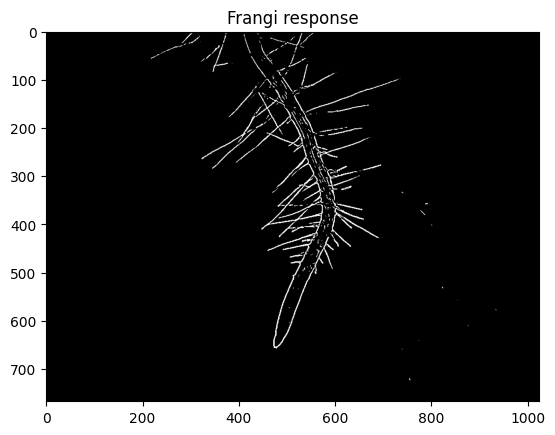

In [25]:
from skimage.filters import frangi

vessel = frangi(image_gray)

_, vessel_mask = cv2.threshold(
    (vessel * 255).astype(np.uint8),
    20,
    255,
    cv2.THRESH_BINARY
)

plt.imshow(vessel_mask, cmap='gray')
plt.title("Frangi response")
plt.show()

binary mask, distance transform, extract core, expand core using original binary mask as limit 

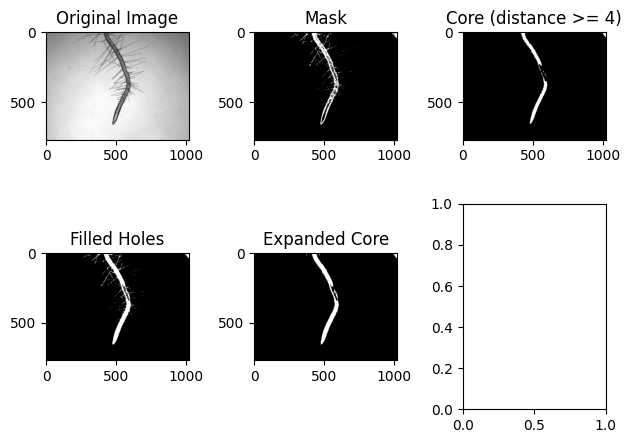

In [26]:
mask

mask_bool = mask > 0
filled_bool = scipy.ndimage.binary_fill_holes(mask_bool)
filled_holes = (filled_bool.astype(np.uint8)) * 255

dist_map = cv2.distanceTransform(filled_holes, cv2.DIST_L2, 5)
core = (dist_map >= 4).astype(np.uint8) * 255

expanded = core.copy()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,10))

for _ in range(2):
    expanded = cv2.dilate(expanded, kernel, iterations=1)
    expanded = cv2.bitwise_and(expanded, filled_holes)

fig, ax = plt.subplots(2,3)

ax[0,0].imshow(image_gray, cmap='gray')
ax[0,0].set_title("Original Image")
ax[0,1].imshow(mask, cmap='gray')
ax[0,1].set_title("Mask")
ax[1,0].imshow(filled_holes, cmap='gray')
ax[1,0].set_title("Filled Holes")
ax[1,1].imshow(expanded, cmap='gray')
ax[1,1].set_title("Expanded Core")
ax[0,2].imshow(core, cmap='gray')
ax[0,2].set_title("Core (distance >= 4)")
plt.tight_layout()
plt.show()


change ellipse size or kernel size
- could try a more vertical kernel 
change number of iterations

Also, keep in mind that we can take the core, and then crop out the distance transform below a certain value. This could be done maybe by finding the tip of the root (minimum kernel, minimum point is bad idea) and then take a percentage or something to remove a portion above RELATIVE to the height of the image as a whole. 

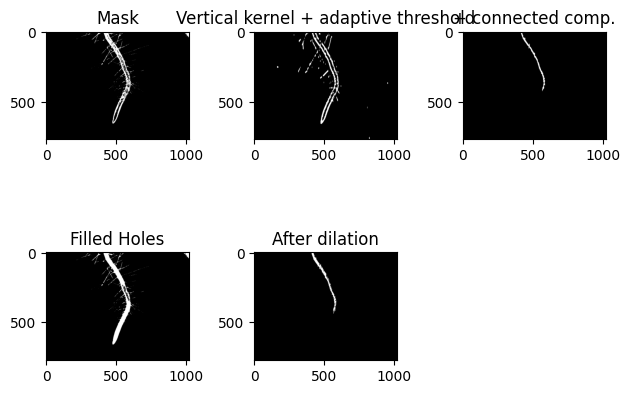

In [27]:
'''1st try:
-	vertical kernel (or ellipse kernel)
-	adaptive threshold 
-	connected component
-	fill in holes
-	dilate to result of connected component 
'''

image_gray
mask

new_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,10)) #vert kernel
# adaptive threshold
new_adapt = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    35,   # block size, must be odd
    8     # constant subtracted
)                                                                # type: ignore
new_opened = cv2.morphologyEx(new_adapt, cv2.MORPH_OPEN, new_kernel)

# connected component
num_labels_new, labels_new, stats_new, centroids_new = cv2.connectedComponentsWithStats(new_opened, connectivity=8)
largest_label_new = 1 + np.argmax(stats_new[1:, cv2.CC_STAT_AREA])
main_root_mask_new = np.zeros_like(new_opened)
main_root_mask_new[labels_new == largest_label_new] = 255

# filled holes
mask_bool = mask > 0
filled_bool_new = scipy.ndimage.binary_fill_holes(mask_bool)
filled_holes_new = (filled_bool_new.astype(np.uint8)) * 255

core = main_root_mask_new.copy()
expanded_new = core.copy()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,10))
for _ in range(2):
    expanded_new = cv2.dilate(expanded_new, kernel, iterations=1)
    expanded_new = cv2.bitwise_and(expanded_new, mask)

fig, ax = plt.subplots(2,3)
ax[0,0].imshow(mask, cmap='gray')
ax[0,0].set_title("Mask")
ax[0,1].imshow(new_opened, cmap='gray')
ax[0,1].set_title("Vertical kernel + adaptive threshold")
ax[0,2].imshow(main_root_mask_new, cmap='gray')
ax[0,2].set_title("+ connected comp.")
ax[1,0].imshow(filled_holes_new, cmap='gray')
ax[1,0].set_title("Filled Holes")
ax[1,1].imshow(expanded_new, cmap='gray')
ax[1,1].set_title("After dilation")
plt.tight_layout()
plt.axis("off")
plt.show()
